<a href="https://colab.research.google.com/github/rhwndnjs1127-create/Git5603/blob/main/202555603_%EA%B3%A0%EC%A3%BC%EC%9B%90_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
file_uploaded = files.upload()

Saving 부산교통공사_시간대별 승하차인원_20260430 (1).csv to 부산교통공사_시간대별 승하차인원_20260430 (1) (3).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("부산교통공사_시간대별 승하차인원_20260430.csv", encoding='cp949')
df

,역번호,역명,년월일,요일,구분,합계,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
0,95,다대포해수욕장,2026-01-01,목,승차,7526,0,0,1,11,...,371,275,315,239,110,96,66,55,7,0
1,95,다대포해수욕장,2026-01-01,목,하차,7357,0,0,1,0,...,238,330,246,139,129,101,88,67,52,44
2,95,다대포해수욕장,2026-01-02,금,승차,4135,0,0,0,28,...,325,290,300,246,116,81,78,74,19,1
3,95,다대포해수욕장,2026-01-02,금,하차,3177,0,0,0,1,...,240,306,296,270,204,127,105,108,84,53
4,95,다대포해수욕장,2026-01-03,토,승차,4114,1,0,0,17,...,392,374,326,208,151,107,111,68,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26875,414,안평,2026-04-28,화,하차,2177,0,0,0,0,...,154,161,188,167,137,88,68,80,25,12
26876,414,안평,2026-04-29,수,승차,2260,0,0,1,7,...,141,158,212,170,56,46,19,14,6,0
26877,414,안평,2026-04-29,수,하차,2171,0,0,1,1,...,142,136,198,179,101,79,74,75,49,23
26878,414,안평,2026-04-30,목,승차,2287,0,0,0,4,...,154,191,225,195,60,42,19,12,9,0


In [3]:
pnu = df[df['역명'] == '부산대']
pnu.head()

,역번호,역명,년월일,요일,구분,합계,01시-02시,02시-03시,03시-04시,04시-05시,...,15시-16시,16시-17시,17시-18시,18시-19시,19시-20시,20시-21시,21시-22시,22시-23시,23시-24시,24시-01시
2046,128,부산대,2026-01-01,목,승차,7765,0,0,0,5,...,598,661,794,581,486,443,401,263,156,16
2047,128,부산대,2026-01-01,목,하차,7969,0,0,0,0,...,708,674,747,590,474,365,286,219,146,40
2048,128,부산대,2026-01-02,금,승차,13172,0,0,0,1,...,881,1021,1088,1333,752,584,595,467,268,15
2049,128,부산대,2026-01-02,금,하차,13256,0,0,0,0,...,1032,1007,1248,1582,906,493,417,357,271,71
2050,128,부산대,2026-01-03,토,승차,11353,0,0,0,0,...,901,1042,997,873,654,513,569,456,248,13


In [4]:
daily = (pnu.groupby(['년월일', '요일'])['합계'].sum().reset_index())
daily['년월일'] = pd.to_datetime(daily['년월일'])

print(daily['년월일'].min())
print(daily['년월일'].max())
daily.head()

2026-01-01 00:00:00
2026-04-30 00:00:00


,년월일,요일,합계
0,2026-01-01,목,15734
1,2026-01-02,금,26428
2,2026-01-03,토,22660
3,2026-01-04,일,18300
4,2026-01-05,월,28236


In [5]:
daily['평일/주말'] = daily['요일'].apply(lambda x: '주말' if x in ['토', '일'] else '평일')
daily['평일/주말'].value_counts()
daily.head()

,년월일,요일,합계,평일/주말
0,2026-01-01,목,15734,평일
1,2026-01-02,금,26428,평일
2,2026-01-03,토,22660,주말
3,2026-01-04,일,18300,주말
4,2026-01-05,월,28236,평일


In [6]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

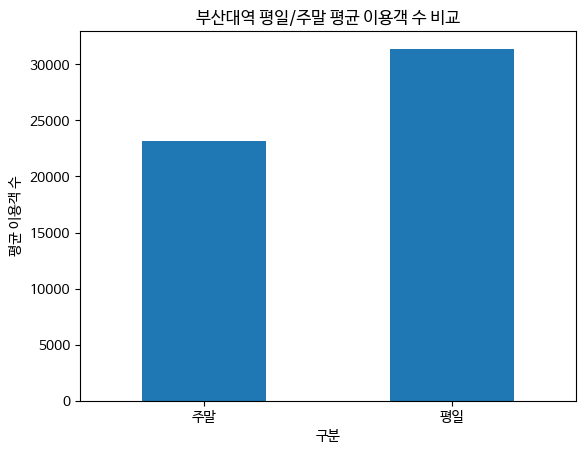

In [7]:
plt.rc('font', family='NanumBarunGothic')
daily.groupby('평일/주말')['합계'].mean().plot(kind='bar')

plt.title('부산대역 평일/주말 평균 이용객 수 비교')
plt.xlabel('구분')
plt.ylabel('평균 이용객 수')
plt.xticks(rotation=0)
plt.show()

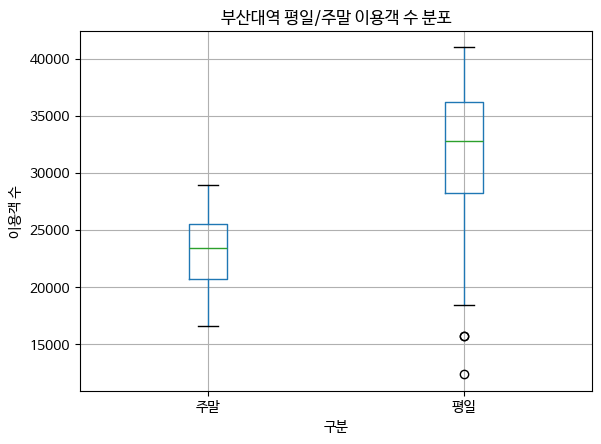

In [8]:
# 어느 정도나 차이나는지 확인
daily.boxplot(column='합계', by='평일/주말')

plt.title('부산대역 평일/주말 이용객 수 분포')
plt.suptitle('')
plt.xlabel('구분')
plt.ylabel('이용객 수')
plt.show()

In [9]:
# 각 요일별 구분
order = ['월', '화', '수', '목', '금', '토', '일']
weekday_mean = (daily.groupby('요일')['합계'].mean().reindex(order))
weekday_mean

,합계
요일,
월,29893.529412
화,31069.529412
수,31591.470588
목,31967.888889
금,32407.647059
토,26034.176471
일,20231.352941


In [10]:
weekday = daily[daily['평일/주말'] == '평일']['합계']
weekend = daily[daily['평일/주말'] == '주말']['합계']
actual_diff = weekday.mean() - weekend.mean()
print(actual_diff)

8260.01436388509


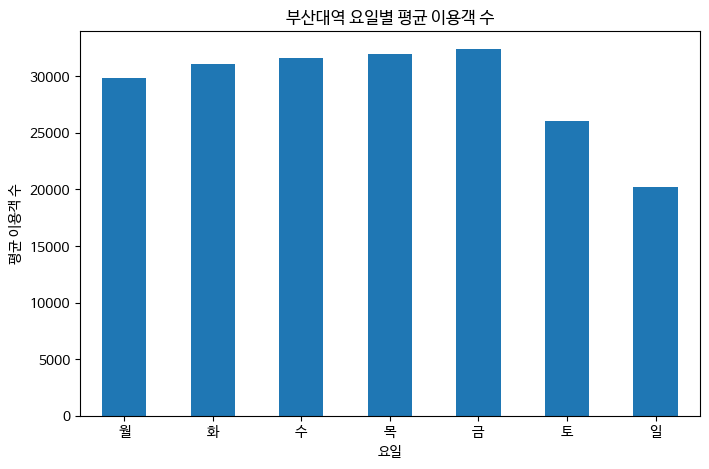

In [11]:
# 요일별 평균 이용객 수
weekday_summary = daily.groupby('요일')['합계'].agg(['count', 'mean', 'std'])
plt.figure(figsize=(8,5))
weekday_mean.plot(kind='bar')

plt.title('부산대역 요일별 평균 이용객 수')
plt.xlabel('요일')
plt.ylabel('평균 이용객 수')
plt.xticks(rotation=0)
plt.show()

In [12]:
# 평균 차이 구하기
mon_thu = daily[daily['요일'].isin(['월', '화', '수', '목'])]['합계']
fri = daily[daily['요일'] == '금']['합계']
print("월~목 평균\t", mon_thu.mean())
print("금 평균\t\t", fri.mean())
actual_diff = fri.mean() - mon_thu.mean()
print("평균 차이\t", actual_diff)

월~목 평균	 31142.739130434784
금 평균		 32407.647058823528
평균 차이	 1264.907928388744


In [13]:
import numpy as np
np.random.seed(42)

bootarray = []
for _ in range(10000):
    sample_mon_to_thu = np.random.choice(mon_thu, size=len(mon_thu), replace=True)
    sample_fri = np.random.choice(fri, size=len(fri), replace=True)
    diff = sample_fri.mean() - sample_mon_to_thu.mean()
    bootarray.append(diff)

bootarray = np.array(bootarray)
p_value = np.mean(bootarray <= 0)
print(p_value)

0.1382


In [14]:
lower = np.percentile(bootarray, 2.5)
upper = np.percentile(bootarray, 97.5)

print("95% 신뢰구간: ")
print(f"[{lower:.2f}, {upper:.2f}]")

95% 신뢰구간: 
[-991.56, 3494.75]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


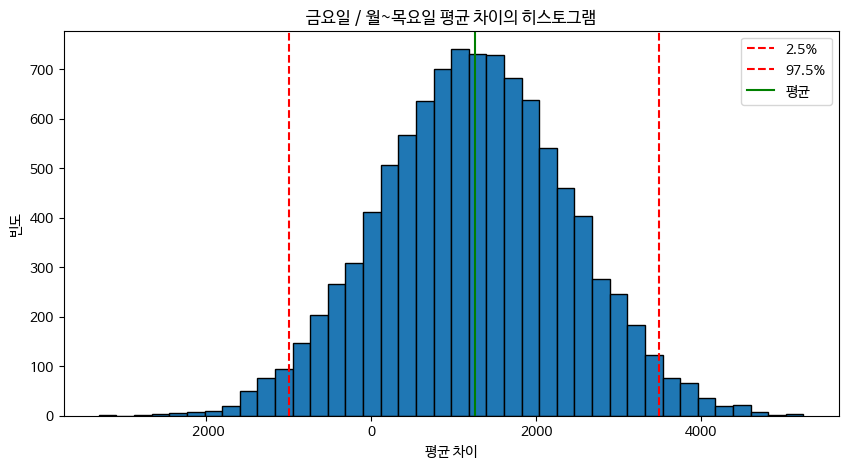

In [15]:
plt.figure(figsize=(10,5))

plt.hist(
    bootarray,
    bins=40,
    edgecolor='black'
)

plt.axvline(lower,
            color='red',
            linestyle='--',
            label='2.5%')

plt.axvline(upper,
            color='red',
            linestyle='--',
            label='97.5%')

plt.axvline(
    bootarray.mean(),
    color='green',
    linestyle='-',
    label='평균'
)

plt.title('금요일 / 월~목요일 평균 차이의 히스토그램')
plt.xlabel('평균 차이')
plt.ylabel('빈도')

plt.legend()
plt.show()